**Gobernanza, calidad de datos, mitigación de sesgos, transparencia y comprensión**

1. Instalación de Librerías Especializadas

In [ ]:
# Instalación de librerías para explicabilidad y equidad
!pip install shap fairlearn lime LightGBM

2. Carga de Datos y Réplica del Modelo

In [ ]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Librerías de Gobernanza, Equidad y XAI
import shap
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference

In [ ]:
# Carga del dataset ──────────────────────────────────────────────────────
url_github = 'https://raw.githubusercontent.com/jhonquimi-png/Aprendizaje_Automatico/refs/heads/main/data/student_performance.csv'
df = pd.read_csv(url_github, low_memory=False)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 500 filas × 11 columnas


In [ ]:
# Preprocesamiento rápido orientado a mantener consistencia
# Eliminamos ID que no aporta valor predictivo
X = df.drop(columns=['student_id', 'final_score', 'passed'])
y = df['passed'].map({'Yes': 1, 'No': 0})

# Guardamos la variable sensible antes de codificar para la auditoría de sesgo
X_sensitive_gender = X['gender']

# Codificación de variables categóricas
categorical_cols = X.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Partición de datos
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X, y, X_sensitive_gender, test_size=0.2, random_state=42, stratify=y
)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo de clasificación (ejemplo: RandomForest que suele ser base sólida)
model = RandomForestClassifier(random_state=42, max_depth=8)
model.fit(X_train_scaled, y_train)

print("¡Modelo entrenado y listo para auditoría de gobernanza!")

¡Modelo entrenado y listo para auditoría de gobernanza!


3. Bloque 1 - Auditoría de Sesgos (Fairness)

=== MÉTRICAS DESAGREGADAS POR GÉNERO ===
        accuracy  selection_rate
gender                          
Female  0.898305        0.627119
Male    0.804878        0.634146

=== ÍNDICES DE DISPARIDAD ===
Diferencia en Paridad Demográfica: 0.0070 (Ideal: 0)
Diferencia en Igualdad de Oportunidades: 0.1667 (Ideal: 0)


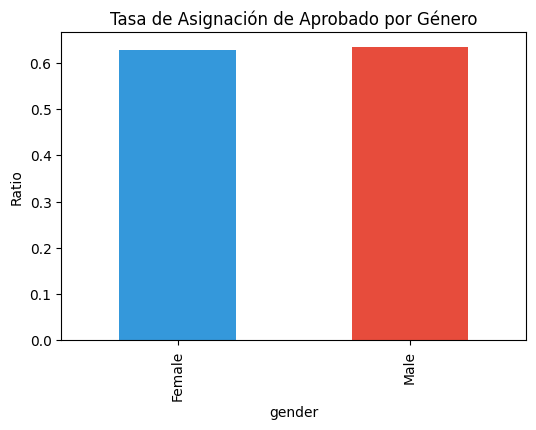

In [ ]:
# Evaluamos las métricas de rendimiento desagregadas por la variable sensible (Gender)
y_pred = model.predict(X_test_scaled)

# Estructuramos el dataframe de métricas de Fairlearn
metrics = {
    'accuracy': lambda y_true, y_pred: (y_true == y_pred).mean(),
    'selection_rate': selection_rate # Tasa de asignación del estado "Aprobado"
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)

print("=== MÉTRICAS DESAGREGADAS POR GÉNERO ===")
print(metric_frame.by_group)

# Cálculo de disparidades fundamentales
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=gender_test)

print("\n=== ÍNDICES DE DISPARIDAD ===")
print(colóquese_alerta := f"Diferencia en Paridad Demográfica: {dp_diff:.4f} (Ideal: 0)")
print(f"Diferencia en Igualdad de Oportunidades: {eo_diff:.4f} (Ideal: 0)")

# Gráfico de la tasa de selección por grupo
metric_frame.by_group['selection_rate'].plot(kind='bar', color=['#3498db', '#e74c3c'], figsize=(6,4))
plt.title('Tasa de Asignación de Aprobado por Género')
plt.ylabel('Ratio')
plt.show()

### Interpretación de métricas de equidad

El análisis de equidad mostró que la tasa de selección entre hombres y mujeres es bastante similar, con una diferencia de paridad demográfica de apenas 0.007, lo que sugiere que el modelo no presenta un sesgo fuerte en la asignación de estudiantes aprobados.

Sin embargo, la diferencia de igualdad de oportunidades fue de 0.1667, indicando que el comportamiento del modelo no es completamente uniforme entre grupos. Esto puede reflejar diferencias en la forma en que el modelo comete errores para cada género.

Además, se observó una mayor precisión en las predicciones para el grupo femenino respecto al masculino, lo que evidencia la importancia de evaluar métricas desagregadas y no únicamente el desempeño global del modelo.

Estos resultados muestran que, aunque el modelo presenta un comportamiento relativamente equilibrado, aún existen oportunidades de mejora para reducir posibles disparidades y fortalecer la equidad del sistema.

4. Bloque 2 - Explicabilidad Global y Local (XAI con SHAP y LIME)

=== EXPLICABILIDAD GLOBAL ===


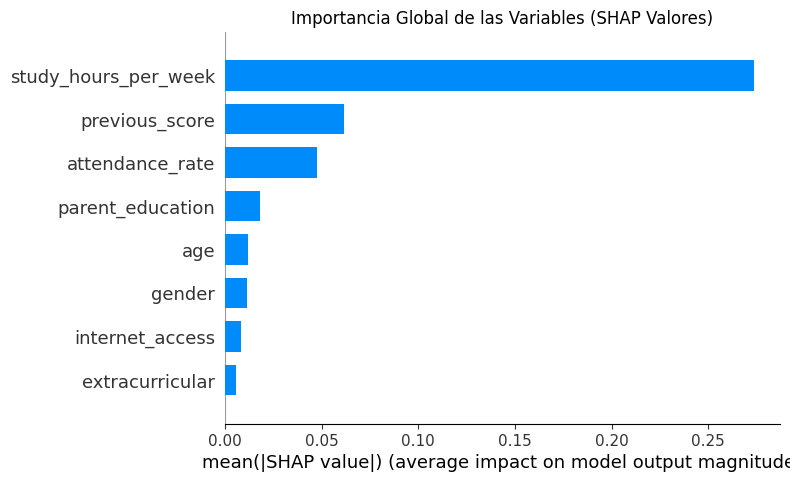

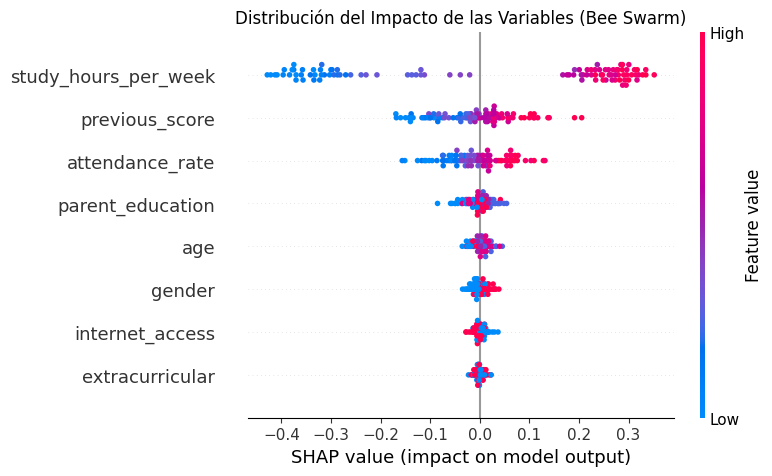


=== EXPLICABILIDAD LOCAL (Caso de estudio individual) ===


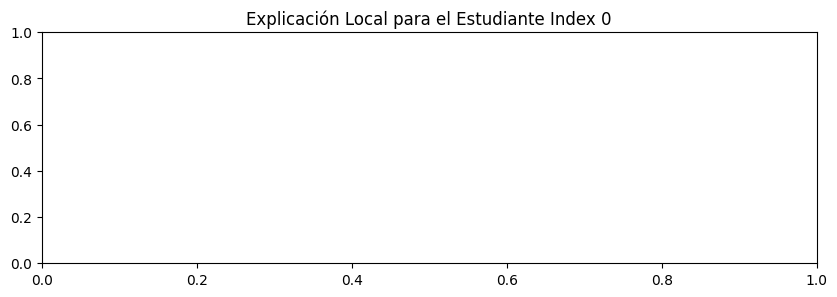

=== CONFIGURANDO LIME PARA EXPLICABILIDAD LOCAL ===

Explicación Local con LIME para el Estudiante Index 0:



=== CASO DE ESTUDIO INDIVIDUAL 2 (Estudiante Index 1) ===


<Figure size 1000x300 with 0 Axes>

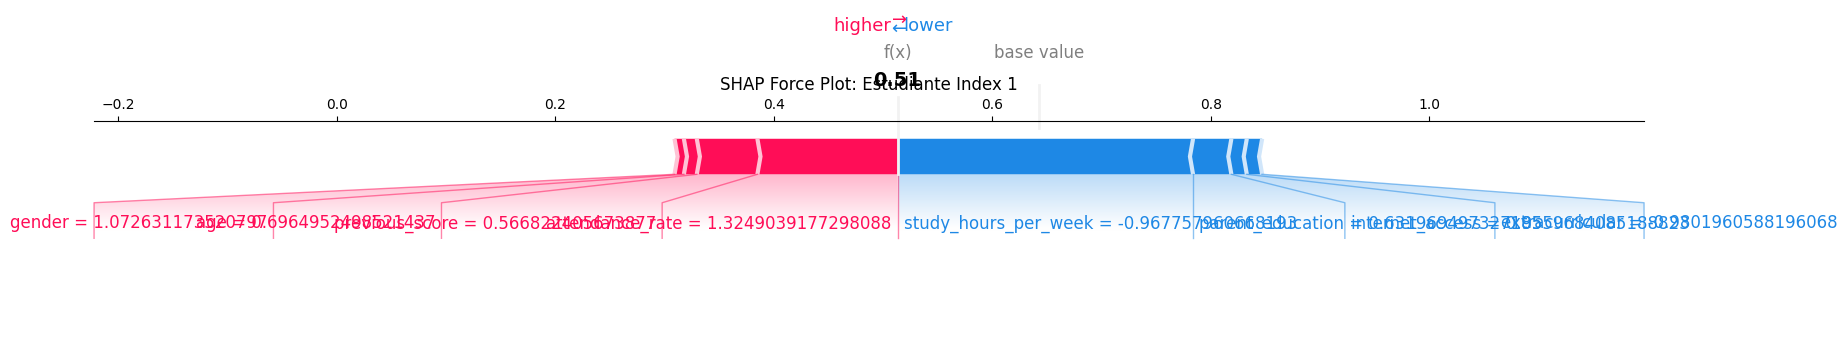

Explicación Local con LIME para el Estudiante Index 1:


In [ ]:
# Inicializar el explicador SHAP (utiliza TreeExplainer para modelos basados en árboles)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# Nota: En binario, shap_values puede devolver una lista para ambas clases [Clase 0, Clase 1].
# Usamos el índice 1 para referirnos al impacto sobre "Aprobar (Yes)".
# Corregimos la forma de obtener shap_v para el caso de ndarray.
shap_v = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

print("=== EXPLICABILIDAD GLOBAL ===")
# Resumen global de impacto de características
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_v, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)
plt.title('Importancia Global de las Variables (SHAP Valores)')
plt.show()

# Gráfico de abanico detallado (Bee Swarm)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_v, X_test_scaled, feature_names=X.columns, show=False)
plt.title('Distribución del Impacto de las Variables (Bee Swarm)')
plt.show()

print("\n=== EXPLICABILIDAD LOCAL (Caso de estudio individual) ===")
# Tomamos el primer estudiante de la muestra de testeo
idx_estudiante = 0

# Gráfico de fuerza (Force Plot) para entender una predicción específica
plt.figure(figsize=(10, 3))
shap.plots.force(explainer.expected_value[1], shap_v[idx_estudiante], pd.DataFrame(X_test_scaled, columns=X.columns).iloc[idx_estudiante], show=False)
plt.title(f'Explicación Local para el Estudiante Index {idx_estudiante}')
plt.show()


# Inicializar el explicador LIME
import lime
import lime.lime_tabular

print("=== CONFIGURANDO LIME PARA EXPLICABILIDAD LOCAL ===")

# LIME requiere funciones que reciban arreglos de numpy y un formato específico de datos
# Creamos el explicador de LIME para datos tabulares
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['Reprobado (No)', 'Aprobado (Yes)'],
    mode='classification',
    random_state=42
)

# Explicamos exactamente al mismo estudiante (idx_estudiante = 0) usado en SHAP
# Nota: Pasamos la probabilidad de predicción del modelo (.predict_proba)
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_scaled[idx_estudiante],
    predict_fn=model.predict_proba,
    num_features=5
)

# Visualización de LIME en el Notebook
print(f"\nExplicación Local con LIME para el Estudiante Index {idx_estudiante}:")
lime_exp.show_in_notebook(show_table=True)

# ==============================================================================
# EJEMPLO COMPARATIVO
# ==============================================================================
idx_estudiante_2 = 1 # Seleccionamos otro estudiante con características contrastantes
print(f"\n=== CASO DE ESTUDIO INDIVIDUAL 2 (Estudiante Index {idx_estudiante_2}) ===")

# 1. SHAP para Estudiante 2
plt.figure(figsize=(10, 3))
shap.plots.force(
    explainer.expected_value[1],
    shap_v[idx_estudiante_2],
    pd.DataFrame(X_test_scaled, columns=X.columns).iloc[idx_estudiante_2],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot: Estudiante Index {idx_estudiante_2}')
plt.show()

# 2. LIME para Estudiante 2
lime_exp_2 = lime_explainer.explain_instance(
    data_row=X_test_scaled[idx_estudiante_2],
    predict_fn=model.predict_proba,
    num_features=5
)
print(f"Explicación Local con LIME para el Estudiante Index {idx_estudiante_2}:")
lime_exp_2.show_in_notebook(show_table=True)


## 5. Análisis Interpretativo y Reflexivo sobre Gobernanza de IA

### Transparencia del Modelo

Uno de los principales desafíos de los modelos de Machine Learning es evitar que funcionen como una “caja negra”. En este proyecto, las técnicas SHAP y LIME permitieron comprender cómo el modelo toma decisiones y qué variables influyen más en las predicciones.

Los resultados de SHAP mostraron que la variable con mayor impacto fue la cantidad de horas de estudio por semana (study_hours_per_week), seguida por el rendimiento previo (previous_score) y la asistencia (attendance_rate). Además, las explicaciones locales permitieron analizar casos individuales y entender por qué el modelo predijo aprobación o reprobación para estudiantes específicos.

Esto aporta mayor transparencia y permite interpretar el comportamiento del modelo de una forma más comprensible y auditable.

### Riesgos Éticos y Sociales en la Implementación del Sistema

Si este tipo de sistema se implementa en un entorno educativo real sin supervisión adecuada, podrían generarse riesgos importantes.

Por ejemplo, un docente podría verse influenciado negativamente si observa que un estudiante tiene alta probabilidad de reprobar, afectando indirectamente el apoyo que recibe el alumno. También existe el riesgo de reforzar desigualdades si variables relacionadas con acceso a recursos tecnológicos o condiciones socioeconómicas terminan influyendo en las decisiones del modelo.

Además, utilizar automáticamente estas predicciones para asignar becas, beneficios o restricciones académicas podría generar decisiones injustas si no existe revisión humana.

### Consideraciones para Mejorar el Modelo

Como mejoras futuras, sería recomendable continuar monitoreando posibles sesgos del modelo mediante herramientas de equidad como Fairlearn y revisar periódicamente el comportamiento de las variables utilizadas.

También sería útil incorporar variables adicionales relacionadas con apoyo emocional, contexto familiar o acompañamiento académico, ya que el rendimiento estudiantil no depende únicamente de factores cuantitativos.

Finalmente, mantener mecanismos de explicabilidad resulta fundamental para garantizar transparencia, confianza y supervisión humana en sistemas automatizados de apoyo a decisiones.

## 6. Conclusiones y Respuestas al Cuestionario de la Tarea

### ¿Qué aprendizaje desarrolló sobre cómo el modelo toma decisiones?

El principal aprendizaje fue comprender que el modelo no toma decisiones utilizando una sola variable, sino mediante la combinación de múltiples factores que influyen simultáneamente en la predicción final. Las técnicas SHAP y LIME permitieron entender cómo variables como las horas de estudio, el rendimiento previo y la asistencia afectan positiva o negativamente la probabilidad de aprobación de cada estudiante.

Además, se observó que SHAP resulta útil para interpretar el comportamiento global del modelo, mientras que LIME facilita la explicación de casos individuales de manera más intuitiva y visual.

### ¿Hay alguna variable que tenga un peso excesivo?

A partir del análisis global de SHAP, se identificó que la variable con mayor influencia fue la cantidad de horas de estudio por semana (study_hours_per_week), seguida por el rendimiento previo y la asistencia.

Aunque estas variables tienen relación lógica con el desempeño académico, depender excesivamente de una sola característica podría limitar la capacidad del modelo para comprender situaciones particulares de ciertos estudiantes. Por ejemplo, un alumno con dificultades de asistencia podría igualmente tener un buen rendimiento por factores externos no considerados en el dataset.

### ¿Qué pasaría si este modelo se implementa sin explicabilidad?

Implementar un modelo sin mecanismos de explicabilidad generaría riesgos importantes en términos de transparencia y confianza. Si un estudiante fuese clasificado con riesgo de reprobación, docentes o directivos no podrían comprender claramente qué factores llevaron a esa decisión.

La ausencia de explicaciones dificultaría la toma de acciones correctivas específicas y podría generar desconfianza en el sistema. Por esta razón, herramientas como SHAP y LIME son importantes, ya que permiten interpretar las predicciones y entender el comportamiento del modelo de forma más transparente y responsable.